# Family B — the dispersion premium as a carry book

The grid's episodic harness gave a quarterly-resolving premium 1–3 trades
per config — and it was *structurally* starved: the lab quotes are
OTM-only, so modal flys straddling the money silently lost legs. Here the
surface is parity-completed (C = P + DF·(F−K), ~0.03bp error on settle
forwards) and the premium is held as rank-based rolled BOOKS, marked
daily, with attribution into ordinary carry / decision windows / expiry
settlements / costs — the variance-risk-premium methodology on the
lattice.

Books (all defined LONG the structure; short = mirror with the same
costs): FLY25, FLY50 (long fly = short dispersion), DFLY (count-skew),
STRG50/75 (the off-lattice tails, true put+call), CAL (long Q3 fly,
short Q1 fly — the frontier-slope compression carry). Ranks Q1–Q3.

In [1]:
import datetime
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from famb_common import (
    FAMB, TreeCtx, attribution, book_daily_pnl, build_book, load_quotes,
    n_contracts, premium_surface, sr3_forwards, structure_legs,
)
from RVUtils.SFRRVLab.stats import nw_tstat
from SDRUtils.analytics.fomc import load_fomc_schedule

BOOKS = ["FLY25", "FLY50", "DFLY", "STRG50", "STRG75"]
RANKS = [1, 2, 3]

quotes = load_quotes()
symbols = sorted(quotes["symbol"].unique())
fwd = sr3_forwards(symbols)
fwd["as_of"] = pd.to_datetime(fwd["as_of"])
surface = premium_surface(quotes, fwd)
fwd_idx = fwd.set_index(["as_of", "symbol"])["fwd_rate"].sort_index()
dates = pd.DatetimeIndex(sorted(quotes["as_of"].unique()))
tree = TreeCtx([d.date() for d in dates])
fomc = load_fomc_schedule("USD-SOFR-1D")
decisions = [pd.Timestamp(d).date() for d in fomc["effective_date"]
             if dates[0] <= pd.Timestamp(d) <= dates[-1]]
print(f"quotes {len(quotes)} rows, {len(symbols)} symbols, "
      f"{dates[0].date()} -> {dates[-1].date()}, {len(decisions)} decisions")

quotes 199313 rows, 14 symbols, 2024-07-01 -> 2026-07-28, 16 decisions


## The books: coverage and headline stats

NW t-stats (autocorrelation-robust) on daily PnL; both signs shown —
short = −gross with identical costs. Sharpe annualised off dailies.

In [2]:
books, rows = {}, []
for book in BOOKS:
    for rank in RANKS:
        hs = build_book(book, rank, dates, surface, fwd_idx, tree)
        books[(book, rank)] = hs
        if not hs:
            rows.append({"book": book, "rank": rank, "holdings": 0})
            continue
        pnl = book_daily_pnl(hs, cost_mult=1.0, n_legs=n_contracts(book))
        daily = pnl.groupby("as_of")["pnl_bp"].sum()
        gross = pnl[pnl.kind != "entry_cost"]
        gross = gross[gross.kind != "exit_cost"]["pnl_bp"].sum()
        costs = -pnl[pnl.kind.isin(["entry_cost", "exit_cost"])][
            "pnl_bp"].sum()
        sd = daily.std(ddof=1)
        rows.append({
            "book": book, "rank": rank, "holdings": len(hs),
            "days": int(daily.shape[0]),
            "long_gross_bp": round(float(gross), 1),
            "costs_1x_bp": round(float(costs), 1),
            "long_net_1x": round(float(gross - costs), 1),
            "short_net_1x": round(float(-gross - costs), 1),
            "nw_t_long": round(float(nw_tstat(daily.to_numpy())), 2),
            "sharpe_long": round(float(daily.mean() / sd * np.sqrt(252)), 2)
            if sd > 0 else np.nan,
        })
stats = pd.DataFrame(rows)
print(stats.to_string(index=False))

  book  rank  holdings  days  long_gross_bp  costs_1x_bp  long_net_1x  short_net_1x  nw_t_long  sharpe_long
 FLY25     1         7   408           -6.7          4.0        -10.7           2.7      -0.64        -0.46
 FLY25     2         8   473           -0.9          8.0         -8.9          -7.1      -0.98        -0.52
 FLY25     3         9   521            0.2          9.0         -8.8          -9.2      -1.17        -0.61
 FLY50     1         7   408           12.5          4.0          8.5         -16.5       0.29         0.22
 FLY50     2         8   473           12.5          8.0          4.5         -20.5       0.20         0.13
 FLY50     3         9   510            5.2          9.0         -3.8         -14.2      -0.22        -0.13
  DFLY     1         7   408           -6.8          8.0        -14.8          -1.2      -0.56        -0.41
  DFLY     2         8   473            3.3         16.0        -12.7         -19.3      -1.17        -0.63
  DFLY     3         9   512

## Attribution — where the PnL lives

The fairly-priced-insurance test: does ordinary-day carry offset decision
windows and expiry settlements? A genuine harvest shows up as ordinary
carry the events do not claw back.

In [3]:
att_rows = []
for (book, rank), hs in books.items():
    if not hs:
        continue
    pnl = book_daily_pnl(hs, cost_mult=1.0, n_legs=n_contracts(book))
    att = attribution(pnl, decisions)["sum"]
    att_rows.append({
        "book": book, "rank": rank,
        "ordinary": round(att.get("ordinary", 0.0), 1),
        "decision_window": round(att.get("decision_window", 0.0), 1),
        "settlement": round(att.get("settlement", 0.0), 1),
        "costs": round(att.get("costs", 0.0), 1),
        "total": round(float(att.sum()), 1),
    })
att_table = pd.DataFrame(att_rows)
print(att_table.to_string(index=False))

  book  rank  ordinary  decision_window  settlement  costs  total
 FLY25     1      -3.5             -6.7         3.5   -4.0  -10.7
 FLY25     2       2.1             -3.0         0.0   -8.0   -8.9
 FLY25     3       1.0             -0.8         0.0   -9.0   -8.8
 FLY50     1      21.5            -16.1         7.1   -4.0    8.5
 FLY50     2      26.9            -14.5         0.0   -8.0    4.5
 FLY50     3      12.8             -7.5         0.0   -9.0   -3.8
  DFLY     1     -12.8              1.0         5.0   -8.0  -14.8
  DFLY     2       0.9              2.4         0.0  -16.0  -12.7
  DFLY     3      -0.2              1.2         0.0  -18.0  -17.0
STRG50     1     -26.0              2.0        -3.0   -2.0  -29.0
STRG50     2     -48.0              6.1         0.0   -4.0  -45.9
STRG50     3     -24.6              8.5         0.0   -4.5  -20.6
STRG75     1     -14.5              0.0        -3.0   -2.0  -19.5
STRG75     2     -19.3             -3.2         0.0   -4.0  -26.5
STRG75    

In [4]:
# Forward-drift beta: how much of each book's daily PnL is hedgeable drift?
beta_rows = []
for (book, rank), hs in books.items():
    if not hs:
        continue
    xs, ys = [], []
    for h in hs:
        f = fwd_idx.xs(h.symbol, level="symbol").reindex(h.marks.index)
        df_ = f.diff().dropna()
        dm = h.marks.diff().dropna()
        j = pd.concat([df_, dm], axis=1, keys=["df", "dm"]).dropna()
        xs.append(j["df"].to_numpy())
        ys.append(j["dm"].to_numpy())
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    if len(x) < 20 or x.var() == 0:
        continue
    beta = float(np.cov(x, y)[0, 1] / x.var())
    resid = y - beta * x
    beta_rows.append({
        "book": book, "rank": rank, "beta_bp_per_bp": round(beta / 100.0, 3),
        "hedged_carry_bp_day": round(float(resid.mean()), 3),
        "nw_t_hedged": round(float(nw_tstat(resid)), 2),
    })
print(pd.DataFrame(beta_rows).to_string(index=False))

  book  rank  beta_bp_per_bp  hedged_carry_bp_day  nw_t_hedged
 FLY25     1          -0.032               -0.019        -0.46
 FLY25     2          -0.060                0.020         1.32
 FLY25     3          -0.005                0.001         0.08
 FLY50     1          -0.081                0.028         0.39
 FLY50     2          -0.141                0.079         2.09
 FLY50     3          -0.014                0.013         0.39
  DFLY     1           0.126               -0.053        -0.87
  DFLY     2          -0.007                0.010         0.53
  DFLY     3           0.016               -0.000        -0.01
STRG50     1          -0.073               -0.046        -1.54
STRG50     2           0.062               -0.113        -1.46
STRG50     3          -0.111               -0.015        -0.15
STRG75     1          -0.063               -0.024        -1.23
STRG75     2           0.009               -0.055        -0.94
STRG75     3          -0.045               -0.030      

## CAL — the frontier-slope calendar (long Q3 fly, short Q1 fly)

Kill criterion from the spec: if the calendar's daily PnL has |beta| >
0.8 to the Q1 fly alone, it adds nothing beyond the outright.

In [5]:
q1 = books.get(("FLY25", 1), [])
q3 = books.get(("FLY25", 3), [])
if q1 and q3:
    d1 = book_daily_pnl(q1, cost_mult=1.0, n_legs=4).groupby("as_of")[
        "pnl_bp"].sum()
    d3 = book_daily_pnl(q3, cost_mult=1.0, n_legs=4).groupby("as_of")[
        "pnl_bp"].sum()
    cal = (d3 - d1).dropna()
    j = pd.concat([cal, d1], axis=1, keys=["cal", "q1"]).dropna()
    b = float(np.cov(j["q1"], j["cal"])[0, 1] / j["q1"].var()) \
        if j["q1"].var() > 0 else np.nan
    print(f"CAL: total {cal.sum():+.1f}bp over {len(cal)} days, "
          f"NW t {nw_tstat(cal.to_numpy()):.2f}, beta to Q1 fly {b:+.2f} "
          f"-> {'REDUNDANT (kill criterion)' if abs(b) > 0.8 else 'distinct'}")
else:
    print("CAL: needs both Q1 and Q3 fly books; Q1 coverage begins when the "
          "front-contract quotes exist (extends after the backfill).")

CAL: total +7.7bp over 408 days, NW t 0.46, beta to Q1 fly -0.93 -> REDUNDANT (kill criterion)


## The terminal ledger — what the insurance actually settled at

In [6]:
term_rows = []
for (book, rank), hs in books.items():
    for h in hs:
        if h.terminal_bp is None:
            continue
        term_rows.append({
            "book": book, "rank": rank, "symbol": h.symbol,
            "last_mark_bp": round(float(h.marks.iloc[-1]), 2),
            "settle_bp": round(float(h.terminal_bp), 2),
            "settle_minus_mark": round(float(h.terminal_bp
                                             - h.marks.iloc[-1]), 2),
        })
term = pd.DataFrame(term_rows)
if len(term):
    print(term.sort_values(["book", "symbol"]).to_string(index=False))
else:
    print("no holdings reached expiry inside the sample")

  book  rank symbol  last_mark_bp  settle_bp  settle_minus_mark
  DFLY     1 SFRH25         21.24      20.00              -1.24
  DFLY     1 SFRH26          9.50      13.00               3.50
  DFLY     1 SFRM25          0.00       0.00               0.00
  DFLY     1 SFRM26          7.75       8.75               1.00
  DFLY     1 SFRU25        -18.99     -18.50               0.49
  DFLY     1 SFRZ25          2.75       4.00               1.25
 FLY25     1 SFRH25         21.49      20.00              -1.49
 FLY25     1 SFRH26         17.24      19.00               1.76
 FLY25     1 SFRM25          0.00       0.00               0.00
 FLY25     1 SFRM26          7.75       8.75               1.00
 FLY25     1 SFRU25          2.25       3.25               1.00
 FLY25     1 SFRZ25          2.75       4.00               1.25
 FLY50     1 SFRH25         46.48      45.00              -1.48
 FLY50     1 SFRH26         42.23      44.00               1.77
 FLY50     1 SFRM25         17.74      1

## B3 — the Sep-2024 autopsy (the 50bp cut)

The one "wild" meeting in the modern sample. Question 1: was −50 even an
off-lattice outcome, or did the ZQ lattice's support already span
{−25, −50} (a coin flip, not an insurance event)? Question 2: what did
the fly and the tails do through the week?

ZQ lattice on 2024-09-17: meeting eff 2024-09-18, jump -44.6bp, support (-2, -1), q = 0.22
-50bp outcome ON the two-point support: True — a priced coin flip, NOT an insurance event; the off-lattice premium had nothing to pay for here.


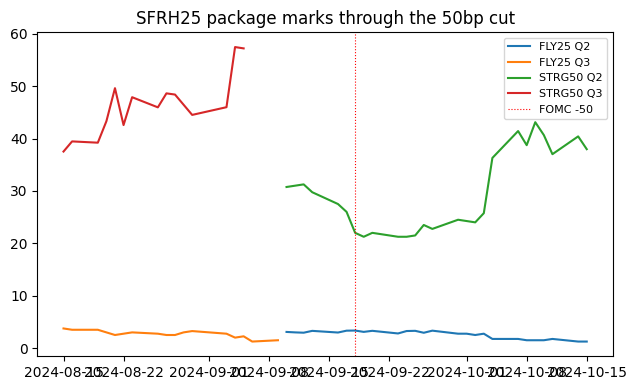

In [7]:
ev = datetime.date(2024, 9, 17)          # eve of the decision
lad = tree.ladders.get(ev) or tree.ladders.get(datetime.date(2024, 9, 16))
if lad:
    m0 = min((m for m in lad if m.effective >= ev),
             key=lambda m: m.effective, default=None)
    if m0 is not None:
        print(f"ZQ lattice on {ev}: meeting eff {m0.effective}, "
              f"jump {m0.jump_bp:+.1f}bp, support {m0.support}, "
              f"q = {m0.q:.2f}")
        on_lattice = m0.support[0] <= -2 <= m0.support[1] or \
            m0.support[0] == -2 or m0.support[1] == -2
        print(f"-50bp outcome ON the two-point support: {on_lattice} — "
              + ("a priced coin flip, NOT an insurance event; the "
                 "off-lattice premium had nothing to pay for here."
                 if on_lattice else
                 "GENUINELY off-lattice; the tails were live."))
autopsy_syms = [s for s in ("SFRZ24", "SFRH25") if s in symbols]
win = (pd.Timestamp("2024-08-15"), pd.Timestamp("2024-10-15"))
fig, axes = plt.subplots(1, max(len(autopsy_syms), 1),
                         figsize=(6.5 * max(len(autopsy_syms), 1), 4),
                         squeeze=False)
for ax, sym in zip(axes[0], autopsy_syms):
    for (book, rank), hs in books.items():
        if book not in ("FLY25", "STRG50"):
            continue
        for h in hs:
            if h.symbol != sym:
                continue
            seg = h.marks[(h.marks.index >= win[0])
                          & (h.marks.index <= win[1])]
            if len(seg):
                ax.plot(seg.index, seg.values, label=f"{book} Q{rank}")
    ax.axvline(pd.Timestamp("2024-09-18"), color="r", lw=0.8, ls=":",
               label="FOMC -50")
    ax.set_title(f"{sym} package marks through the 50bp cut")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
if not autopsy_syms:
    print("neither SFRZ24 nor SFRH25 in the surface yet (backfill pending)")

## Summary (computed above)

The stats, attribution, beta, CAL and terminal tables above ARE the
findings; the findings doc quotes them. Key reads: whether any long or
short book clears costs with |NW t| > 2; whether ordinary carry survives
the settlement ledger; whether the calendar is distinct from the outright;
and what Sep-2024 says the "insurance event" actually was.